In [27]:
import os
import tarfile
from six.moves import urllib
import pandas as pd
import numpy as np 


housing = pd.read_csv('../datasets/housing/housing.csv')

In [28]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [29]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [30]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [31]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [32]:
import matplotlib.pyplot as plt 

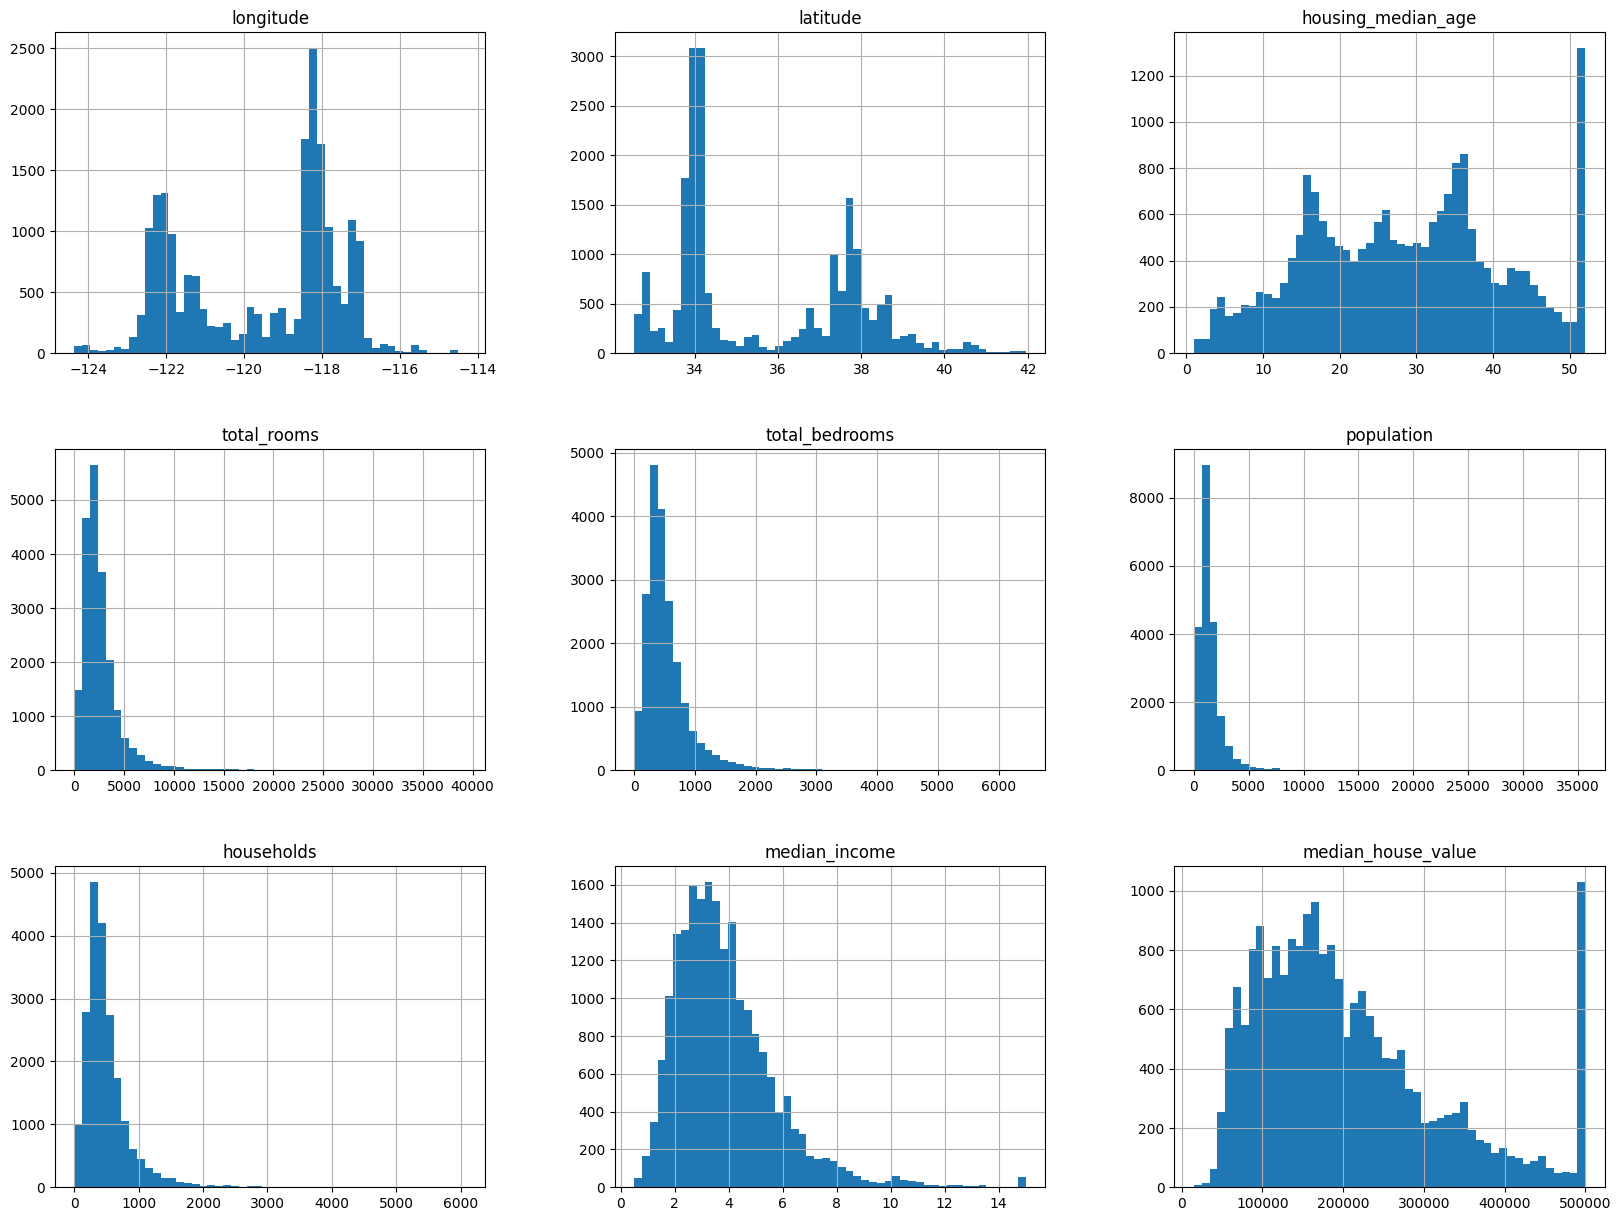

In [33]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [36]:
housing[housing['housing_median_age']==52]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20142,-119.06,34.36,52.0,1239.0,320.0,934.0,298.0,1.8618,183300.0,<1H OCEAN
20220,-119.27,34.28,52.0,2239.0,420.0,941.0,397.0,4.1250,349000.0,NEAR OCEAN
20236,-119.27,34.27,52.0,459.0,112.0,276.0,107.0,2.3750,198400.0,NEAR OCEAN
20237,-119.27,34.27,52.0,1577.0,343.0,836.0,335.0,3.5893,206600.0,NEAR OCEAN


In [37]:
housing = housing[~(housing['median_house_value']==500001) & ~(housing['housing_median_age']==52)]


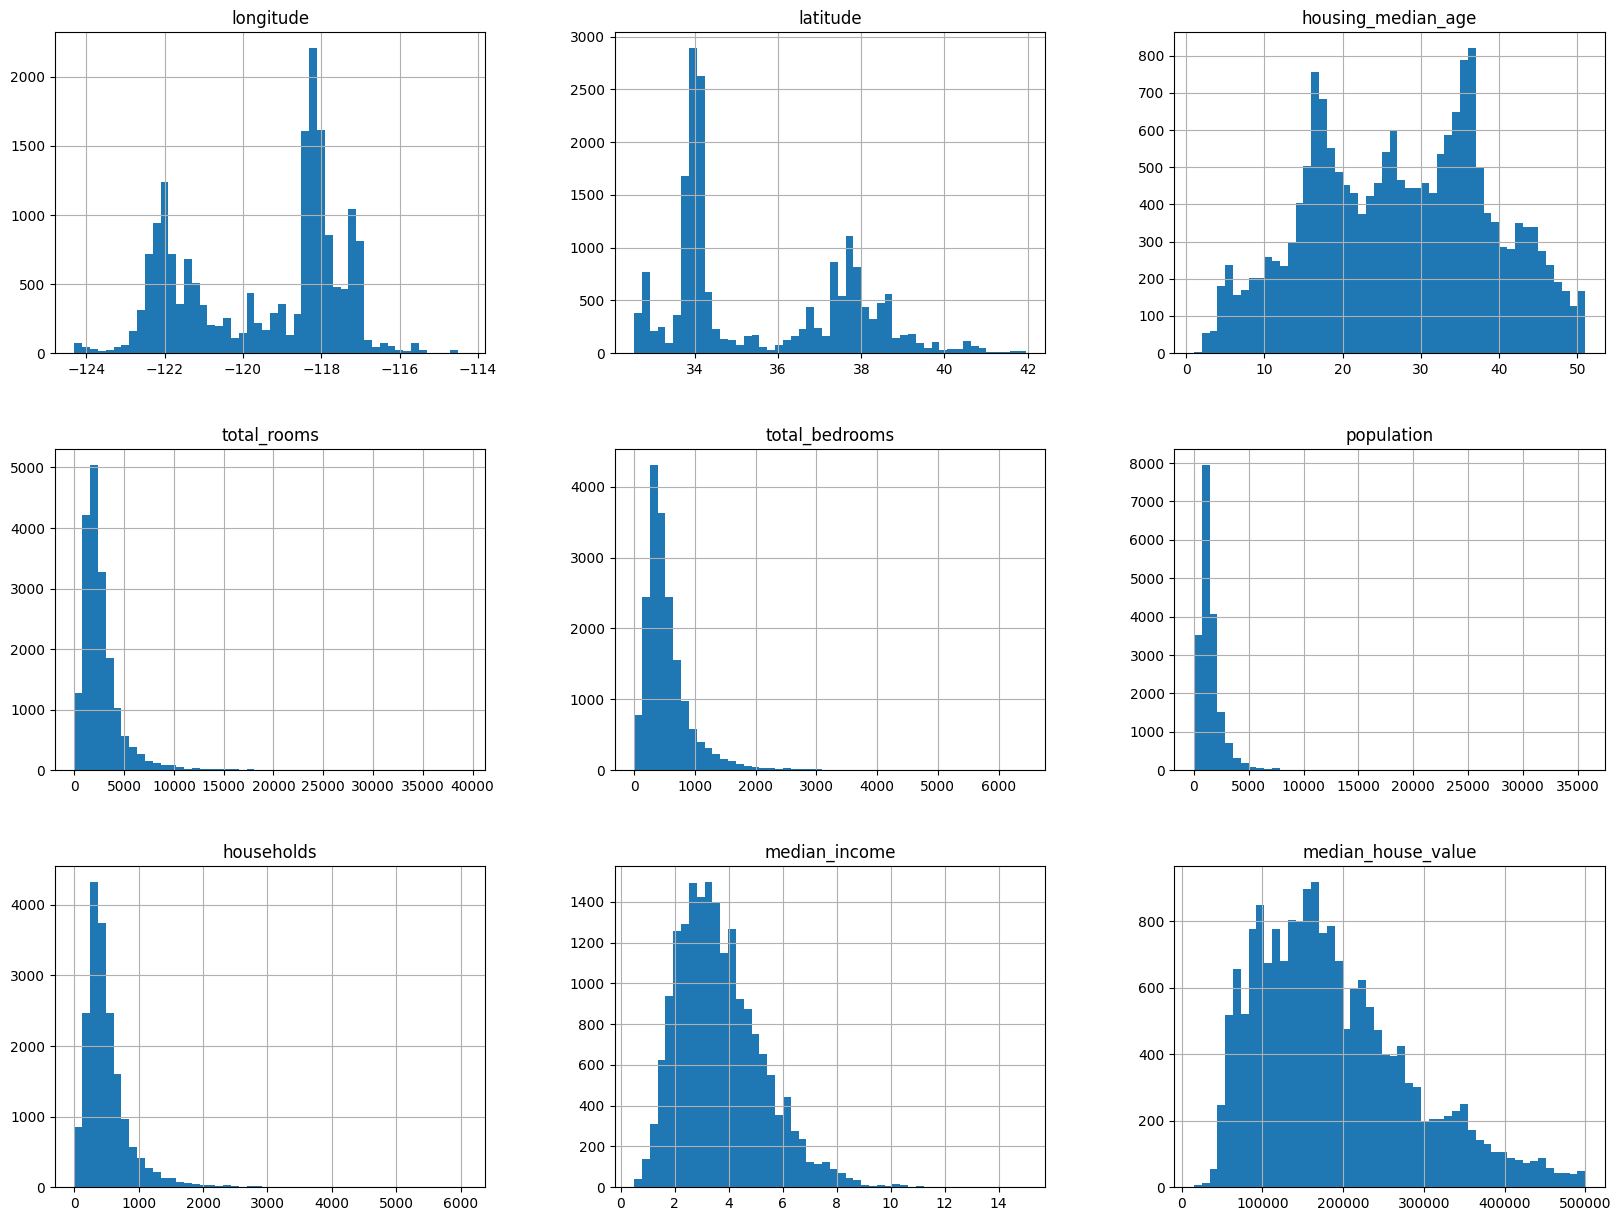

In [39]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [16]:
train_set.shape, test_set.shape

((16512, 10), (4128, 10))

In [17]:
import hashlib

def test_set_check(identifier, test_ratio, hash):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

def split_train_test_by_id(data, test_ratio, id_column, hash=hashlib.md5):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio, hash))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [18]:
train_set, test_set = split_train_test_by_id(housing.reset_index(), 0.2, "index")

Caso eu queira usar uma identificação para garantir via hash que sempre que eu adicionar novos dados eu usar uma hash table pra identificar o dado globalmente e não ter vazamento de dados

In [19]:
def test_set_check(identifier, test_ratio, hash):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

def split_train_test_by_id(data,test_ratio, id_column, hash=hashlib.md5):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio, hash))
    return data.loc[~in_test_set], data.loc[in_test_set]

Fazendo uso da train_test_split fica mais fácil estratificar a amostragem dos dados

In [20]:
housing['income_cat'] = np.ceil(housing['median_income']/1.5)
housing['income_cat'] = housing['income_cat'].where(housing['income_cat'] < 5, 5.0)

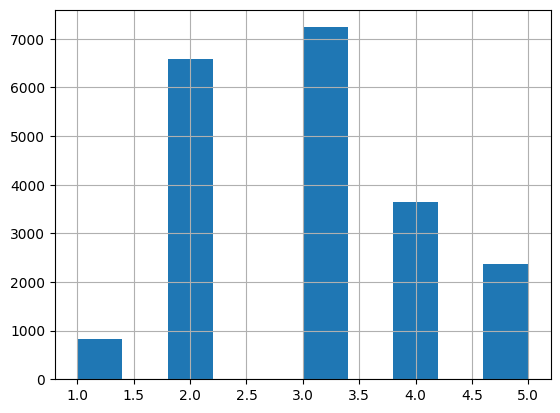

In [21]:
housing['income_cat'].hist()
plt.show()

Maneira moderna de fazer o split 

In [22]:
train_set, test_set = train_test_split(housing, test_size=0.2, stratify=housing['income_cat'], random_state=42)

Como é possível verificar, ambos possuem a mesma estratificação de renda no test_set 

In [23]:
train_set['income_cat'].value_counts(normalize=True)

income_cat
3.0    0.350594
2.0    0.318859
4.0    0.176296
5.0    0.114462
1.0    0.039789
Name: proportion, dtype: float64

In [24]:
test_set['income_cat'].value_counts(normalize=True)

income_cat
3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114341
1.0    0.039971
Name: proportion, dtype: float64

Maneira do Gueron de fazer

In [25]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [26]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [27]:
housing = strat_train_set.copy()

In [28]:
housing_cat = housing['ocean_proximity']

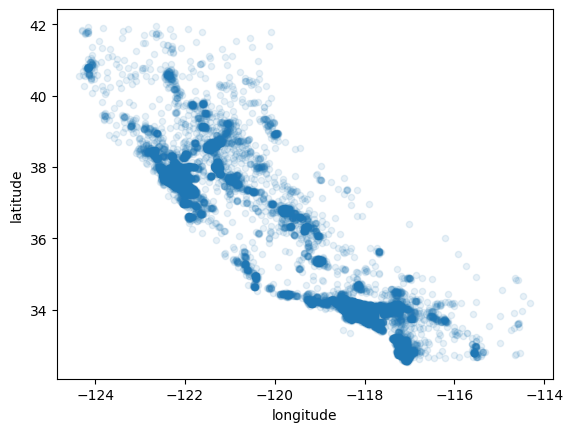

In [29]:
#Verificando a densidade das casas de cada um dos bairros
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.1)
plt.show()

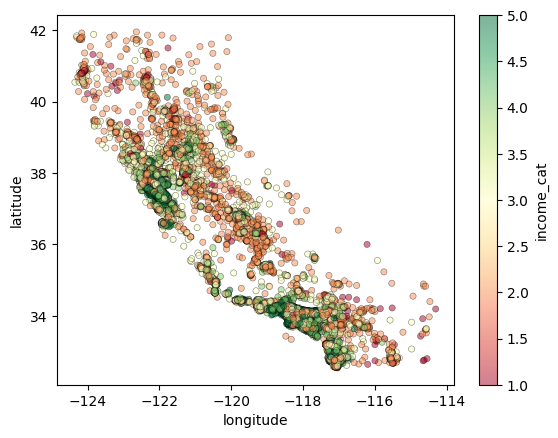

In [30]:
# Visualizando a distribuição espacial das pessoas com base na renda 
housing['income_cat'] = np.ceil(housing['median_income']/1.5)
housing['income_cat'] = housing['income_cat'].where(housing['income_cat'] < 5, 5.0)

housing.plot(kind='scatter', 
             x='longitude', 
             y='latitude', 
             alpha=0.5, 
             c='income_cat', 
             cmap='RdYlGn',
             edgecolor='black',
             linewidth=0.4)
plt.show()

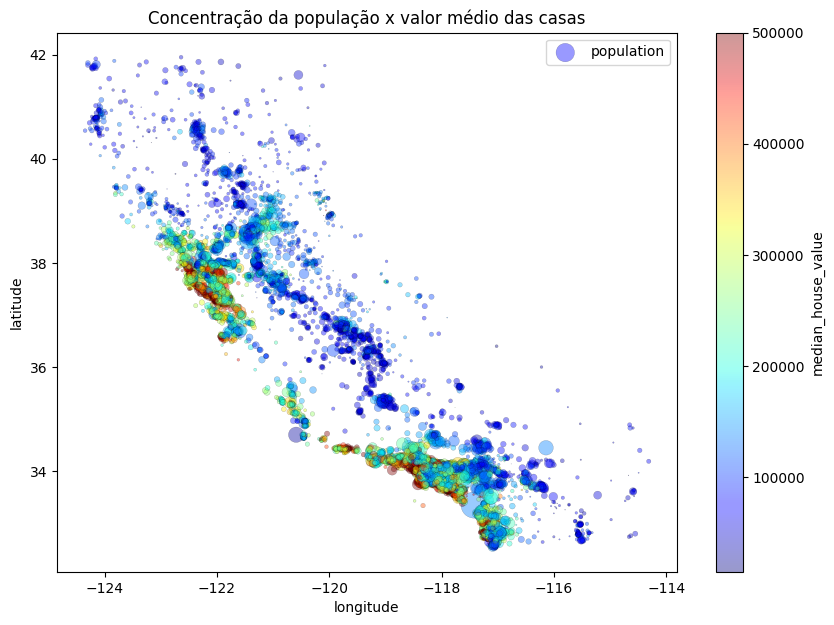

In [31]:
housing.plot(kind='scatter', x='longitude', y='latitude', alpha =0.4,
             s=housing['population']/100, label='population', figsize=(10,7),
             c='median_house_value', cmap='jet', colorbar=True,
             edgecolor = 'black', linewidth = 0.2
             )

plt.legend()
plt.title('Concentração da população x valor médio das casas')
plt.show() 


In [32]:
corr_matrix = housing.corr(numeric_only=True)

In [33]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
income_cat            0.642256
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

In [34]:
from pandas.plotting import scatter_matrix

In [35]:
attributes = ['median_house_value', 'median_income','total_rooms','housing_median_age']

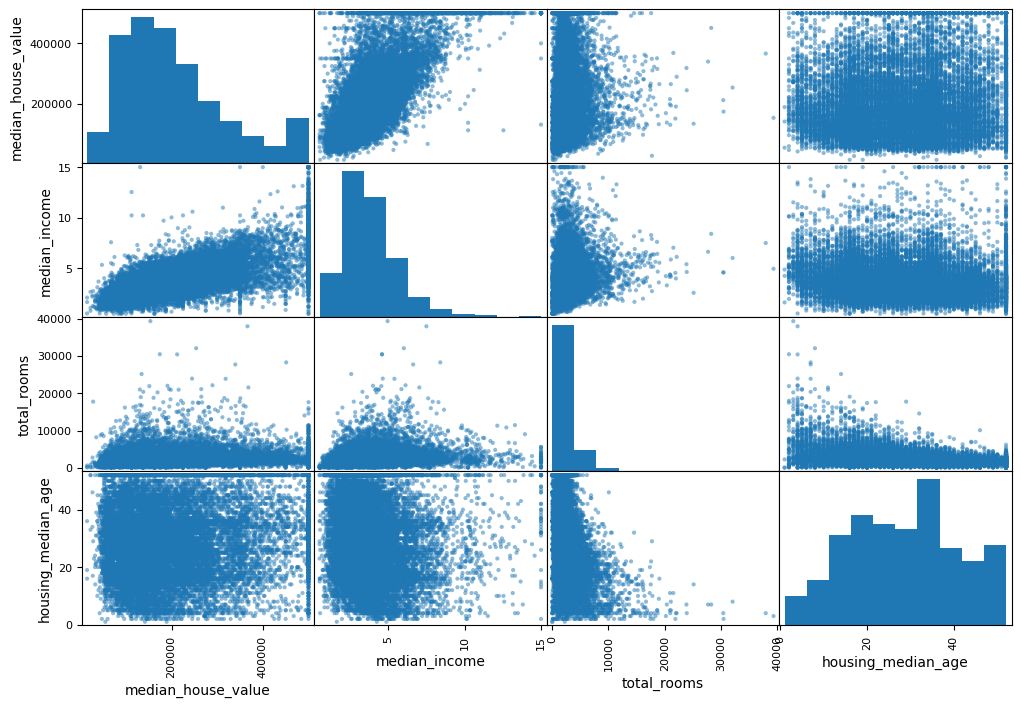

In [36]:
scatter_matrix(housing[attributes], figsize=(12,8))
plt.show()

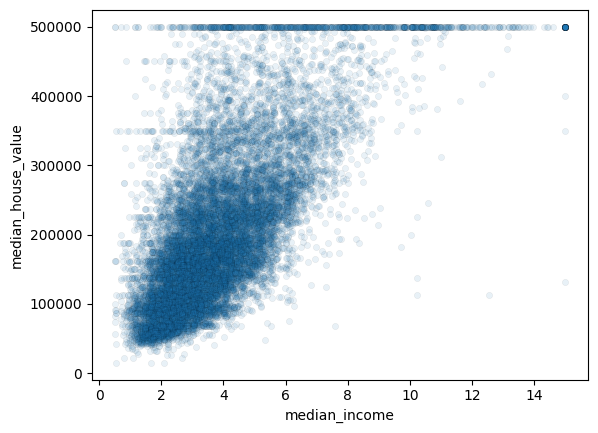

In [37]:
housing.plot(kind="scatter",
             x="median_income", 
             y="median_house_value",
             alpha=0.1,
             edgecolor = 'black',
             linewidth = 0.3
             )
plt.show()

In [38]:
housing['rooms_per_household'] = housing['total_rooms']/housing['households']
housing['beedroms_per_room'] = housing['total_bedrooms']/housing['total_rooms']
housing['population_per_household'] = housing['population']/housing['households']

In [39]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
income_cat                  0.642256
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
beedroms_per_room          -0.259952
Name: median_house_value, dtype: float64

Aqui começamos o processo de limpeza dos dados

In [40]:
housing = strat_train_set.drop('median_house_value', axis=1) 
housing_labels = strat_train_set['median_house_value'].copy()

In [41]:
# # dropar as linhas em que total_bedrooms é nulo 
# housing.dropna(subset=['total_bedrooms']) # opção 1

# # dropar a coluna inteira, o que parece uma péssima opção
# housing.drop("total_bedrooms", axis=1) # opção 2 

# # Preencher os nulos com a mediana dos valores do treino, porém sem uso de um imputer
# median = housing['total_bedrooms'].median() # opção 3 
# housing['total_bedrooms'].fillna(median, inplace=True)

In [42]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
housing_num = housing.drop('ocean_proximity', axis=1)
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [43]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [44]:
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X,columns=housing_num.columns)

In [45]:
housing_cat = housing['ocean_proximity']
housing_cat.head(10)

12655        INLAND
15502    NEAR OCEAN
2908         INLAND
14053    NEAR OCEAN
20496     <1H OCEAN
1481       NEAR BAY
18125     <1H OCEAN
5830      <1H OCEAN
17989     <1H OCEAN
4861      <1H OCEAN
Name: ocean_proximity, dtype: str

a abordagem abaixo não é a mais adequada porque os numeros que ficam próximos entre si são tidos como mais semelhantes, o que não é necessariamente o caso

In [46]:
housing_cat_encoded, housing_categories = housing_cat.factorize()

print(housing_cat_encoded[:10])
print(housing_categories)


[0 1 0 1 2 3 2 2 2 2]
Index(['INLAND', 'NEAR OCEAN', '<1H OCEAN', 'NEAR BAY', 'ISLAND'], dtype='str')


In [47]:
from sklearn.preprocessing import OneHotEncoder

In [48]:
encoder = OneHotEncoder()

In [49]:
housing_cat_1hot = encoder.fit_transform(housing[['ocean_proximity']])

In [50]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [51]:
encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

Customizando transformadores

In [52]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, household_ix = 3, 4, 5, 6

In [53]:
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self,X, y=None):
        return self 
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:,household_ix]
        population_per_household = X[:, population_ix] / X[:, household_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix]/ X[:,rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else: 
            return np.c_[X, rooms_per_household, population_per_household]

In [54]:
# Exemplo usando o CombinedAttributes Adder
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

Exemplo mais prático usando o proprio modelo de dataframe, com isso conseguimos construir um transformador que funciona dentro do pipeline, é obrigatório ter a função fit e transform mesmo que a função fit seja inutil

In [55]:
class CombinedAttributesAdder2(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    
    def fit(self,X,y=None):
        return self 
    
    def transform(self,X): 
        X = X.copy()
        X['rooms_per_household'] = X['total_rooms']/X['households']
        X['population_per_household'] = X['population']/X['households']

        if self.add_bedrooms_per_room:
            X['bedrooms_per_room'] = X['total_bedrooms']/X['total_rooms']
        
        return X 

In [56]:
atts_adder = CombinedAttributesAdder2(add_bedrooms_per_room=False)
housing_extra_attribs_2 = atts_adder.transform(housing)

Implementando Pipelines

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

new_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

housing_num_tr = new_pipeline.fit_transform(housing_num)


In [58]:
housing_num_tr

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.01739526,
         0.00622264, -0.12112176],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.56925554,
        -0.04081077, -0.81086696],
       [ 0.26758118, -0.1259716 ,  1.22045984, ..., -0.01802432,
        -0.07537122, -0.33827252],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ..., -0.5092404 ,
        -0.03743619,  0.32286937],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.32814891,
        -0.05915604, -0.45702273],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.01407228,
         0.00657083, -0.12169672]], shape=(16512, 11))

Agora vou implementar conforme o livro sugere, mas não é a minha ideia de melhor prática, até porque hoje em dia a maioria dos pipelines tem formas de tratamentos que podem ter o output do tipo pandas

In [59]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion

class DataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names
    
    def fit(self, X, y=None):
        return self # Serve somenta para que possa ser utilizada em pipeline
    def transform(self, X):
        return X[self.attribute_names].values
num_attribs = list(housing_num)
cat_attribs = ['ocean_proximity']

num_pipeline = Pipeline([
    ('selector', DataFrameSelector(num_attribs)),
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()), 
])

cat_pipeline = Pipeline([
    ('selector', DataFrameSelector(cat_attribs)),
    ('onehot', OneHotEncoder())
])


full_pipeline = FeatureUnion(transformer_list=[
    ('num_pipeline', num_pipeline),
    ('cat_piepeline', cat_pipeline)
])
housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared = housing_prepared.toarray()

Versão moderna

In [60]:
from sklearn.compose import ColumnTransformer


num_attribs = housing.select_dtypes(include='number').columns
cat_attribs = housing.select_dtypes(exclude='number').columns

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder()),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs),
]) 

housing_prepared_modern = preprocessor.fit_transform(housing)

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_catego

Como mostrado no teste abaixo, a abordagem moderna é mais simples e provê o mesmo resultado, inclusive sendo mais fácil de transformar em um dataframe podendo usar o .set_output(transform='pandas')

In [61]:
np.array_equal(housing_prepared, housing_prepared_modern)

True

Apenas a célula abaixo fará todo o papel de treinar e atribuir os parâmetros ao modelo, ajustando-o aos nossos dados

In [62]:
from sklearn.linear_model import LinearRegression


lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
from sklearn.metrics import mean_squared_error 

housing_predictions = lin_reg.predict(housing_prepared_modern)

In [64]:
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print('MSE', lin_mse)
print('RMSE', lin_rmse)

MSE 4709785076.06003
RMSE 68627.87390018745


In [65]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor() 
tree_reg.fit(housing_prepared_modern, housing_labels)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [66]:
housing_predictions_tree = tree_reg.predict(housing_prepared_modern)

Perceba que estamos treinando o modelo e testando no próprio treino, o que não é nem perto de ser o ideal, mas dá uma ideia se há underfitting, nesse caso, como o resultado do erro foi 0, podemos assumir que houve quase que certamente um overfitting fruto de termos testado o modelo e avaliado no mesmo conjunto de dados completo em ambas etapas

In [67]:
lin_mse = mean_squared_error(housing_labels,housing_predictions_tree)
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

0.0


In [68]:
from sklearn.model_selection import cross_val_score 
scores = cross_val_score(tree_reg, housing_prepared_modern, housing_labels,
                         scoring='neg_mean_squared_error', cv=10)

tree_rmse_scores = np.sqrt(-scores) 

In [69]:
def display_scores(scores):
    print('Scores', scores)
    print("Mean:", scores.mean())
    print("Std Deviation", scores.std())


In [70]:
display_scores(tree_rmse_scores)

Scores [73377.62475505 69654.16384423 68362.68229014 72845.85219653
 71478.04245644 77760.44711631 71849.76236534 73340.90293145
 68471.64298947 71071.38047931]
Mean: 71821.25014242614
Std Deviation 2638.451217359982


In [71]:
lin_scores = cross_val_score(lin_reg, housing_prepared_modern, housing_labels,
                             scoring='neg_mean_squared_error', cv=10)

lin_rmse_scores = np.sqrt(-lin_scores)

display_scores(lin_rmse_scores)

Scores [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247063
Std Deviation 2880.3282098180584


In [72]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor() 

rf_scores = cross_val_score(rf_reg, housing_prepared_modern, housing_labels,
                            scoring = 'neg_mean_squared_error', cv=10)

rf_rmse_scores = np.sqrt(-rf_scores)

rf_reg.fit(housing_prepared_modern, housing_labels)

display_scores(rf_rmse_scores)

Scores [51442.47536151 48916.40574471 46876.84961415 52221.69092834
 47878.47579772 51782.01235162 52242.41532536 49672.42439855
 48740.48255693 53997.3507199 ]
Mean: 50377.05827987662
Std Deviation 2165.6528651578933


Salvando e importando modelos treinados 

In [73]:
import joblib

joblib.dump(rf_reg, f'../models/model{rf_reg.__class__.__name__}.pkl')
my_model = joblib.load('../models/modelRandomForestRegressor.pkl')


Testando multiplos modelos para encontrar os mais promissores

In [74]:
from sklearn.linear_model import Lasso,Ridge
from sklearn.ensemble import AdaBoostRegressor, StackingRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


lasso_reg = Lasso(max_iter=4000)
ridge_reg = Ridge()
svr_reg = SVR()
ada_reg = AdaBoostRegressor()
bgg_reg = BaggingRegressor()
gb_reg = GradientBoostingRegressor()


models = [lasso_reg, ridge_reg, svr_reg, ada_reg, bgg_reg, gb_reg]
for model in models:
    model_score = cross_val_score(model, housing_prepared_modern, housing_labels,
                                  scoring='neg_mean_squared_error', cv=10)

    model_rmse_scores = np.sqrt(-model_score)

    print(model.__class__.__name__)
    display_scores(model_rmse_scores)
    print('--------------------------')
    

Lasso
Scores [71752.4342242  64129.39107077 67768.54013865 68635.90454392
 66844.82981348 72527.59792599 73992.60236629 68802.25715543
 66443.59550893 70139.8776836 ]
Mean: 69103.70304312838
Std Deviation 2876.258898570226
--------------------------
Ridge
Scores [71728.63136675 64160.86509065 67762.03141609 68637.66040731
 66844.98238432 72527.4357689  73993.64349374 68802.57262611
 66444.695624   70140.83639078]
Mean: 69104.33545686475
Std Deviation 2868.991080306089
--------------------------
SVR
Scores [116729.13778306 120113.99351281 113925.04340616 120399.11878641
 114687.49942071 122785.64737282 119853.79338279 118280.31108193
 120230.82615529 118840.1885232 ]
Mean: 118584.55594251942
Std Deviation 2609.6120823493407
--------------------------
AdaBoostRegressor
Scores [82235.49426532 74002.45963893 84149.98665059 80429.65300579
 85810.83496299 88003.26904861 86511.84746411 84049.08602832
 89104.66860938 81823.35048452]
Mean: 83612.06501585693
Std Deviation 4132.090876043285
-----

In [75]:
best_models = [bgg_reg ,gb_reg ,rf_reg]

In [76]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [30,50,60,110,140], 'max_features': [4,6,8,10,12]},
    {'bootstrap': [False], 'n_estimators': [3,10], 'max_features': [2,3,4]}
]

forest_reg = RandomForestRegressor()

grid_search = GridSearchCV(forest_reg, param_grid, cv=5, scoring='neg_mean_squared_error', refit=True)

grid_search.fit(housing_prepared_modern, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [4, 6, ...], 'n_estimators': [30, 50, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [77]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 110}

np.float64(-2416253524.1942453)

In [79]:
cvres = grid_search.cv_results_

In [80]:
for mean_score, params in zip(cvres['mean_test_score'], cvres['params']):
    print(np.sqrt(-mean_score), params)

50204.09338900044 {'max_features': 4, 'n_estimators': 30}
49949.44701775848 {'max_features': 4, 'n_estimators': 50}
49760.184298825065 {'max_features': 4, 'n_estimators': 60}
49640.535306185724 {'max_features': 4, 'n_estimators': 110}
49412.72835059829 {'max_features': 4, 'n_estimators': 140}
50206.73397281718 {'max_features': 6, 'n_estimators': 30}
49705.5230798458 {'max_features': 6, 'n_estimators': 50}
49620.433286291576 {'max_features': 6, 'n_estimators': 60}
49155.40178041723 {'max_features': 6, 'n_estimators': 110}
49191.34740125251 {'max_features': 6, 'n_estimators': 140}
50322.90099924211 {'max_features': 8, 'n_estimators': 30}
49696.83474379665 {'max_features': 8, 'n_estimators': 50}
49503.62557082778 {'max_features': 8, 'n_estimators': 60}
49552.88043727333 {'max_features': 8, 'n_estimators': 110}
49278.60456876231 {'max_features': 8, 'n_estimators': 140}
50344.761705263096 {'max_features': 10, 'n_estimators': 30}
49821.4497420062 {'max_features': 10, 'n_estimators': 50}
4971

In [81]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",110
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [82]:
joblib.dump(grid_search.best_estimator_, '../models/best_rf_model.pkl')
model = joblib.load('../models/best_rf_model.pkl')

In [83]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint 

param_dist = {
    "n_estimators": randint(50,200),
    'max_depth': randint(5,30),
    "max_features": ["sqrt", "log2"],
}

random_search = RandomizedSearchCV(forest_reg, 
                                   param_dist, 
                                   n_iter=20, 
                                   scoring='neg_mean_squared_error',
                                   refit=True)

In [84]:
random_search.fit(housing_prepared_modern, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....001B1D435F4D0>, 'max_features': ['sqrt', 'log2'], 'n_estimators': <scipy.stats....001B1D43CE510>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used

In [85]:
np.sqrt(-random_search.best_score_)

np.float64(49331.51829902928)

In [86]:
random_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",193
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",22
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

Comparando o melhor estimador encontrado, Random_Search vs Grid_Search

In [99]:
random =np.sqrt(-random_search.best_score_)
grid = np.sqrt(-grid_search.best_score_)

if random > grid:
    print(f'Random:{random} foi melhor que o Grid: {grid} por {round(((random/grid)-1)*100,4)}%')
else: 
    print(f'Grid: {grid} foi melhor que o Random:{random}')

Random:49331.51829902928 foi melhor que o Grid: 49155.40178041723 por 0.3583%


In [110]:
random_src_ft = random_search.best_estimator_
feature_importances = random_src_ft.feature_importances_
feature_importances

array([8.27932313e-02, 7.78111281e-02, 4.20390858e-02, 2.37141425e-02,
       2.01523354e-02, 2.27613214e-02, 2.02791466e-02, 2.76789174e-01,
       7.14048441e-02, 1.01143683e-01, 9.19365158e-02, 1.95727970e-02,
       1.37073437e-01, 8.17848335e-05, 5.14921846e-03, 7.29815399e-03])

In [146]:
onehot_attribs = preprocessor.named_transformers_['cat']['onehot']

In [ ]:
housing_extra_attribs = ['rooms_per_household', 'population_per_household', 'bedrooms_per_room']
onehot_attribs = list(onehot_attribs.categories_[0])

num_attribs = num_attribs.to_list()

attributes = num_attribs + housing_extra_attribs + onehot_attribs


In [163]:
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.2767891741744361), 'median_income'),
 (np.float64(0.13707343717989506), 'INLAND'),
 (np.float64(0.10114368333846802), 'population_per_household'),
 (np.float64(0.0919365157924469), 'bedrooms_per_room'),
 (np.float64(0.08279323131955292), 'longitude'),
 (np.float64(0.07781112814466468), 'latitude'),
 (np.float64(0.07140484409304512), 'rooms_per_household'),
 (np.float64(0.042039085797194724), 'housing_median_age'),
 (np.float64(0.02371414250858817), 'total_rooms'),
 (np.float64(0.022761321356106284), 'population'),
 (np.float64(0.02027914658386295), 'households'),
 (np.float64(0.02015233537336106), 'total_bedrooms'),
 (np.float64(0.019572797049550183), '<1H OCEAN'),
 (np.float64(0.007298153993384262), 'NEAR OCEAN'),
 (np.float64(0.005149218461914384), 'NEAR BAY'),
 (np.float64(8.178483352921676e-05), 'ISLAND')]